# Dự đoán giá bất động sản Việt Nam bằng Linear Regression bản production

Notebook này là bản lý thuyết và thực nghiệm đầy đủ cho model dự đoán giá đang dùng trong website HouseSellWeb.

Notebook được viết dựa trên script production `train_vietnam_model.py`, nghĩa là công thức train, feature, dữ liệu, calibration và output model đều bám theo code thật của dự án.

Điểm cần nhớ:

- Model của website vẫn thuộc nhóm Linear Regression.
- Bản production dùng Ridge Linear Regression, tức hồi quy tuyến tính có regularization L2.
- Ridge không phải non-linear model.
- Dataset chính là `tinixai/vietnam-real-estates`.
- Model runtime của backend nằm trong `BE/ml_models/vietnam.pkl`.


## 2. Flow train model

```text
Dataset tinixai/vietnam-real-estates
  -> lấy sample từ Hugging Face hoặc đọc CSV cache
  -> làm sạch text/numeric
  -> lọc loại nhà, giá, diện tích hợp lệ
  -> hiệu chỉnh giá theo thị trường tỉnh/thành
  -> sinh tọa độ latitude/longitude
  -> thêm coverage rows cho 63 tỉnh/thành
  -> augment lên khoảng 35.000 dòng
  -> train Ridge Linear Regression pipeline
  -> đánh giá MAE/R2
  -> lưu vietnam.pkl + metadata
  -> copy sang BE/ml_models để backend Django dùng
```

Backend không chạy notebook. Backend chỉ load file model đã train sẵn.


## 3. Lý thuyết Linear Regression

Hồi quy tuyến tính dự đoán một giá trị liên tục từ nhiều đặc trưng đầu vào.

Với một căn nhà:

```text
x1 = diện tích
x2 = số tầng
x3 = số phòng ngủ
x4 = số phòng tắm
x5 = latitude
x6 = longitude
...
```

Công thức:

$$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

Trong đó:

- $\hat{y}$ là giá dự đoán.
- $\beta_0$ là hệ số chặn.
- $\beta_i$ là trọng số học được.
- $x_i$ là feature đầu vào.

Nhiệm vụ của training là tìm bộ trọng số giúp sai số giữa giá thật và giá dự đoán nhỏ nhất.


## 4. Hàm mất mát và chỉ số đánh giá

Linear Regression thường tối ưu MSE:

$$MSE = \frac{1}{m}\sum_{i=1}^{m}(y_i - \hat{y_i})^2$$

Các chỉ số dùng trong dự án:

| Chỉ số | Ý nghĩa |
| --- | --- |
| MSE | Sai số bình phương trung bình |
| RMSE | Căn của MSE, cùng đơn vị với giá |
| MAE | Sai số tuyệt đối trung bình, dễ giải thích bằng tiền |
| R2 | Tỷ lệ phương sai được mô hình giải thích |

Trong model hiện tại, metric lưu trong `lr_pipeline_metrics.json` gồm MAE và R2.


## 5. Ridge Regression vẫn là Linear Regression

Script production dùng `Ridge(alpha=2.0)` thay vì `LinearRegression()` thuần.

Ridge vẫn dự đoán theo công thức tuyến tính:

$$\hat{y} = \beta_0 + \beta_1x_1 + ... + \beta_nx_n$$

Nhưng hàm loss có thêm regularization L2:

$$Loss = MSE + \alpha\sum_{j=1}^{n}\beta_j^2$$

Ý nghĩa:

- Tránh trọng số quá lớn.
- Giảm overfitting.
- Ổn định hơn khi có nhiều biến one-hot như tỉnh, quận, loại nhà.

Câu trả lời khi bảo vệ:

> Bản production vẫn là Linear Regression. Em dùng Ridge Linear Regression, tức hồi quy tuyến tính có regularization L2 để ổn định hơn trên dữ liệu nhiều tỉnh thành.


## 6. Vì sao log-transform target?

Giá nhà có biên độ rất lớn:

- Có căn vài trăm triệu.
- Có căn vài tỷ.
- Có căn vài chục tỷ.

Nếu train trực tiếp trên giá, outlier giá cao có thể chi phối loss. Vì vậy script dùng:

```text
train:   log1p(price)
predict: expm1(prediction)
```

Trong code:

```python
TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1,
)
```


## 7. Import thư viện và module train production

Notebook import trực tiếp `train_vietnam_model.py` để đảm bảo notebook và script production không lệch công thức.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

ROOT_DIR = Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import train_vietnam_model as tvm

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

DATA_DIR = ROOT_DIR / "data"
MODEL_DIR = ROOT_DIR / "models"

print("Working directory:", ROOT_DIR)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)


Working directory: C:\Users\minht\OneDrive\Desktop\HouseSellWeb\LinearRegressionModel
Data directory: C:\Users\minht\OneDrive\Desktop\HouseSellWeb\LinearRegressionModel\data
Model directory: C:\Users\minht\OneDrive\Desktop\HouseSellWeb\LinearRegressionModel\models


## 8. Kiểm tra file dữ liệu và model

Bảng dưới cho biết các file cache/model hiện có. Nếu các file sample đã tồn tại, notebook không cần tải lại Hugging Face.


In [2]:
important_paths = {
    "raw_sample": tvm.RAW_SAMPLE_PATH,
    "geo_sample": tvm.GEO_SAMPLE_PATH,
    "coverage": tvm.COVERAGE_PATH,
    "augmented": tvm.AUGMENTED_PATH,
    "model": tvm.MODEL_PATH,
    "metadata": tvm.METADATA_PATH,
    "pipeline_model": tvm.PIPELINE_MODEL_PATH,
    "pipeline_metrics": tvm.PIPELINE_METRICS_PATH,
}

rows = []
for name, path in important_paths.items():
    rows.append({
        "name": name,
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / 1024 / 1024, 2) if path.exists() else 0,
        "path": str(path),
    })

paths_df = pd.DataFrame(rows)
print(paths_df.to_string(index=False))


            name  exists  size_mb                                                                                                                     path
      raw_sample    True     1.77          C:\Users\minht\OneDrive\Desktop\HouseSellWeb\LinearRegressionModel\data\tinixai_vietnam_real_estates_sample.csv
      geo_sample    True     1.64      C:\Users\minht\OneDrive\Desktop\HouseSellWeb\LinearRegressionModel\data\tinixai_vietnam_real_estates_geo_sample.csv
        coverage    True     0.34 C:\Users\minht\OneDrive\Desktop\HouseSellWeb\LinearRegressionModel\data\tinixai_vietnam_real_estates_market_coverage.csv
       augmented    True    19.47       C:\Users\minht\OneDrive\Desktop\HouseSellWeb\LinearRegressionModel\data\tinixai_vietnam_real_estates_augmented.csv
           model    True     0.01                                    C:\Users\minht\OneDrive\Desktop\HouseSellWeb\LinearRegressionModel\models\vietnam.pkl
        metadata    True     0.00                          C:\Users\mi

## 9. Đọc dữ liệu gốc từ tinixai/vietnam-real-estates

Script lấy sample từ Hugging Face dataset `tinixai/vietnam-real-estates`. Nếu file CSV cache đã có thì đọc cache để chạy nhanh.


In [3]:
raw_df = tvm.fetch_hf_sample(force_refresh=False)
print("Raw sample shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))
print(raw_df.head(5).to_string(index=False))


Raw sample shape: (2000, 19)
Columns: ['name', 'description', 'property_type_name', 'province_name', 'district_name', 'ward_name', 'street_name', 'project_name', 'price', 'area', 'floor_count', 'frontage_width', 'house_depth', 'road_width', 'bedroom_count', 'bathroom_count', 'house_direction', 'balcony_direction', 'published_at']
                                                                                            name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## 10. Làm sạch dữ liệu

Hàm `clean_real_estate_data()` xử lý:

1. Chuẩn hóa text.
2. Ép numeric cho giá, diện tích, số tầng, số phòng.
3. Lọc property type hợp lệ.
4. Lọc tỉnh/thành có tọa độ.
5. Lọc giá và diện tích trong khoảng hợp lý.
6. Fill missing theo median.
7. Với đất, số tầng/phòng ngủ/phòng tắm về 0.
8. Hiệu chỉnh giá theo thị trường tỉnh/thành.


In [4]:
clean_df = tvm.clean_real_estate_data(raw_df)
print("Clean shape:", clean_df.shape)
print(clean_df[[
    "property_type_name", "province_name", "district_name", "price", "area",
    "floor_count", "bedroom_count", "bathroom_count"
]].head(10).to_string(index=False))


Clean shape: (1815, 19)
  property_type_name province_name district_name       price   area  floor_count  bedroom_count  bathroom_count
                 Nhà        Hà Nội   Bắc Từ Liêm  6907279250  37.00         4.00           4.00            5.00
                 Nhà   Hồ Chí Minh             8  9367748000  48.00         4.00           3.00            3.00
Biệt thự/Nhà liền kề     Vĩnh Long     Bình Minh 13416312500 300.00         4.00           4.00            5.00
     Căn hộ chung cư   Hồ Chí Minh            12  3733761200  44.00         7.00           1.00            1.00
                 Nhà   Hồ Chí Minh       Tân Phú 10801215000  60.00         4.00           2.00            3.00
                 Đất       Đà Nẵng        Cẩm Lệ  6546000000 100.00         0.00           0.00            0.00
                 Nhà   Hồ Chí Minh      Tân Bình 12618856250  77.00         4.00           5.00            3.00
     Căn hộ chung cư     Khánh Hòa     Nha Trang  2844160000  59.00         7.00

## 11. Biểu đồ phân bố giá sau khi làm sạch

Biểu đồ này dùng log scale để nhìn rõ hơn vì giá nhà chênh lệch rất lớn.


count     0.00
mean     13.77
std      14.06
min       0.69
25%       6.38
50%       9.38
75%      15.37
90%      28.42
95%      40.69
max     120.00


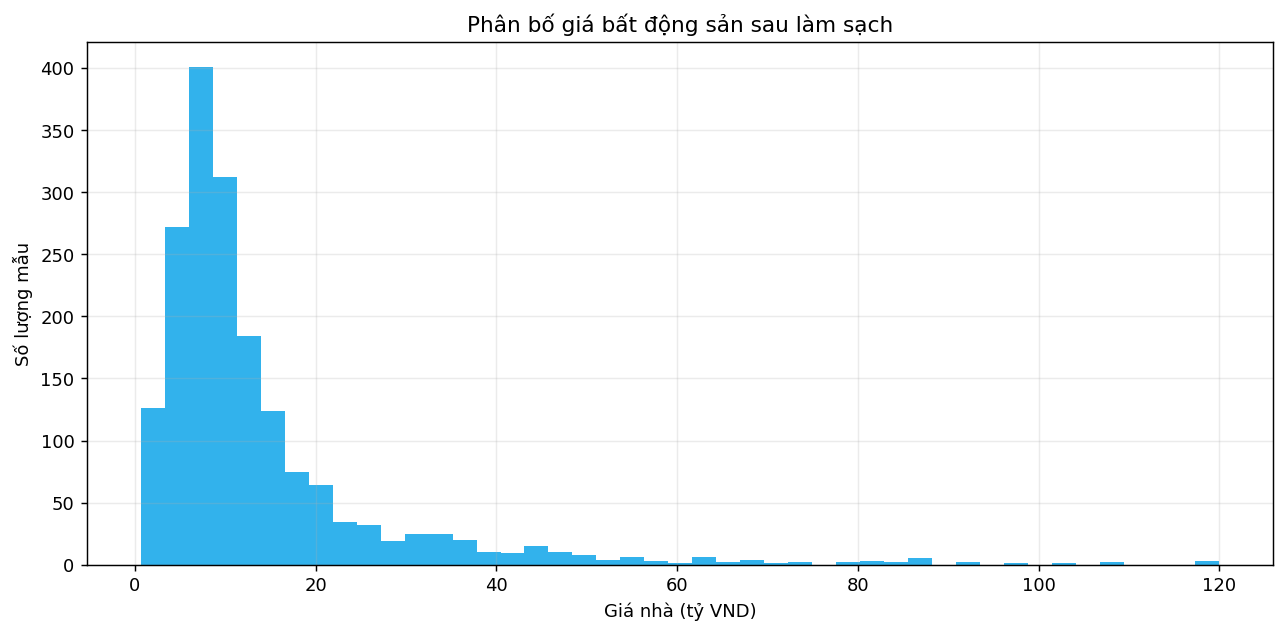

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(clean_df["price"] / 1_000_000_000, bins=45, color="#0ea5e9", alpha=0.85)
plt.xlabel("Giá nhà (tỷ VND)")
plt.ylabel("Số lượng mẫu")
plt.title("Phân bố giá bất động sản sau làm sạch")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

summary = clean_df["price"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]) / 1_000_000_000
print(summary.to_string())


## 12. Market calibration theo tỉnh/thành

Dataset thực tế có thể lệch do sample ít hoặc giá đăng không đồng đều. Script dùng `PROVINCE_PRICE_M2` làm guardrail giá/m2 theo thị trường.

Công thức ý tưởng:

```text
target_price = area * base_price_m2[province] * property_type_multiplier * structure_multiplier
blended_price = observed_price * observed_weight + target_price * (1 - observed_weight)
```

Đây là bước tiền xử lý target, không biến model thành non-linear.


         province  base_price_m2
      Hồ Chí Minh      165000000
           Hà Nội      145000000
          Đà Nẵng       78000000
        Khánh Hòa       70000000
       Bình Dương       58000000
Bà Rịa - Vũng Tàu       56000000
       Quảng Ninh       54000000
        Hải Phòng       52000000
         Đồng Nai       48000000
        Quảng Nam       48000000
         Bắc Ninh       46000000
         Hưng Yên       42000000
       Quảng Ngãi       42000000
          Cần Thơ       40000000
          Long An       40000000


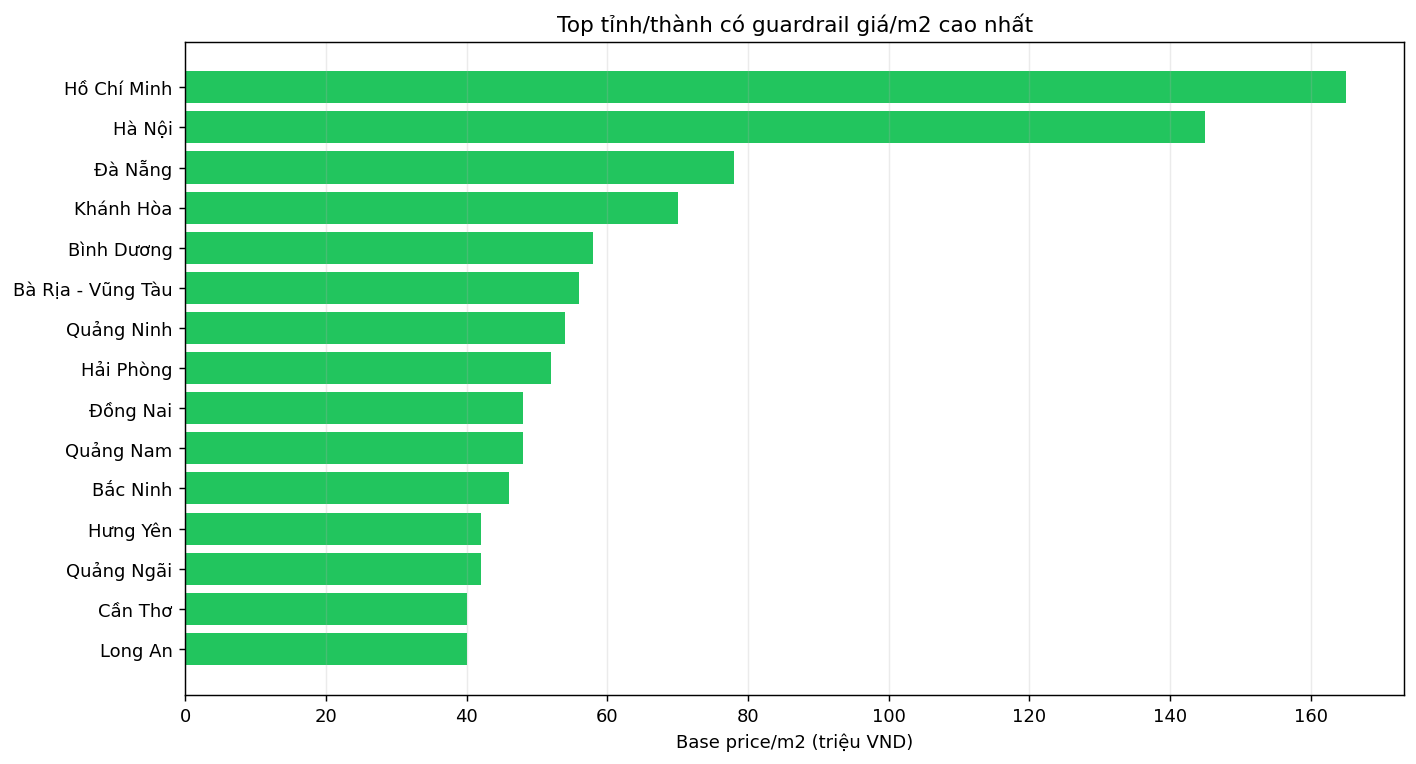

In [6]:
price_m2_df = pd.DataFrame([
    {"province": province, "base_price_m2": price}
    for province, price in tvm.PROVINCE_PRICE_M2.items()
]).sort_values("base_price_m2", ascending=False)

top_price_m2 = price_m2_df.head(15)
plt.figure(figsize=(11, 6))
plt.barh(top_price_m2["province"][::-1], top_price_m2["base_price_m2"][::-1] / 1_000_000, color="#22c55e")
plt.xlabel("Base price/m2 (triệu VND)")
plt.title("Top tỉnh/thành có guardrail giá/m2 cao nhất")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print(top_price_m2.to_string(index=False))


## 13. Tạo tọa độ tổng hợp

Dataset gốc không có latitude/longitude. Script tạo tọa độ bằng cách:

- Dùng tọa độ trung tâm tỉnh trong `PROVINCE_COORDS`.
- Dùng override cho một số quận lớn trong `DISTRICT_COORD_OVERRIDES`.
- Thêm jitter ổn định bằng hash để các record không nằm trùng một điểm.


Geo shape: (1815, 21)
province_name district_name  latitude  longitude
       Hà Nội   Bắc Từ Liêm     21.09     105.76
  Hồ Chí Minh             8     10.73     106.63
    Vĩnh Long     Bình Minh     10.26     105.98
  Hồ Chí Minh            12     10.86     106.63
  Hồ Chí Minh       Tân Phú     10.80     106.64
      Đà Nẵng        Cẩm Lệ     16.00     108.19
  Hồ Chí Minh      Tân Bình     10.80     106.66
    Khánh Hòa     Nha Trang     12.23     109.21
     Đồng Nai      Biên Hòa     10.95     106.85
  Hồ Chí Minh       Tân Phú     10.81     106.64


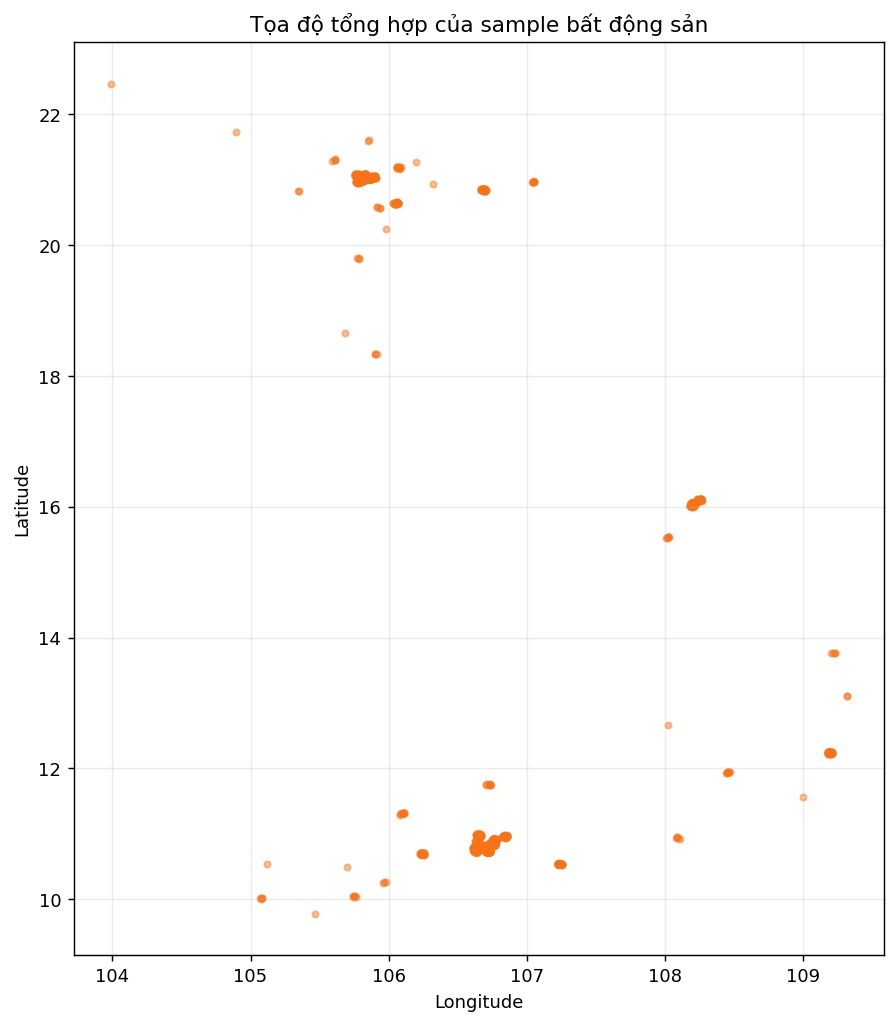

In [7]:
geo_df = tvm.add_synthetic_coordinates(clean_df)
print("Geo shape:", geo_df.shape)
print(geo_df[["province_name", "district_name", "latitude", "longitude"]].head(10).to_string(index=False))

plt.figure(figsize=(7, 8))
plt.scatter(geo_df["longitude"], geo_df["latitude"], s=12, alpha=0.45, color="#f97316")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Tọa độ tổng hợp của sample bất động sản")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 14. Coverage rows cho 63 tỉnh/thành

Nếu sample chỉ có một số tỉnh nhiều dữ liệu, model sẽ yếu khi user chọn tỉnh ít xuất hiện. Vì vậy script sinh thêm coverage rows để đủ 63 tỉnh/thành cũ.


In [8]:
coverage_df = tvm.make_coverage_records()
print("Coverage shape:", coverage_df.shape)
print("Coverage province count:", coverage_df["province_name"].nunique())
print(coverage_df[[
    "property_type_name", "province_name", "district_name", "area", "price", "latitude", "longitude"
]].head(10).to_string(index=False))


Coverage shape: (1775, 15)
Coverage province count: 63
  property_type_name province_name district_name   area      price  latitude  longitude
Biệt thự/Nhà liền kề      An Giang     Trung tâm  45.00 1535923647     10.55     105.13
Biệt thự/Nhà liền kề      An Giang     Trung tâm  60.00 2296348493     10.51     105.11
Biệt thự/Nhà liền kề      An Giang     Trung tâm  80.00 3090745798     10.55     105.13
Biệt thự/Nhà liền kề      An Giang     Trung tâm 120.00 4376390608     10.54     105.13
Biệt thự/Nhà liền kề      An Giang     Trung tâm 180.00 6422755521     10.50     105.11
     Căn hộ chung cư      An Giang     Trung tâm  45.00  948256547     10.51     105.12
     Căn hộ chung cư      An Giang     Trung tâm  60.00 1112454543     10.53     105.10
     Căn hộ chung cư      An Giang     Trung tâm  80.00 1513921576     10.53     105.11
     Căn hộ chung cư      An Giang     Trung tâm 120.00 2343073156     10.53     105.13
     Căn hộ chung cư      An Giang     Trung tâm 180.00 350686669

## 15. Augmentation dữ liệu

Script augment dữ liệu để model học mượt hơn quanh các điểm dữ liệu:

- Thay đổi nhẹ diện tích.
- Thay đổi nhẹ giá.
- Thay đổi nhẹ số tầng/phòng.
- Thay đổi nhẹ tọa độ.

Mục tiêu là đạt khoảng 35.000 dòng train.


Base shape: (3590, 22)
Augmented shape: (35000, 22)
          stage  rows
     Raw sample  2000
      Clean geo  1815
       Coverage  1775
Augmented train 35000


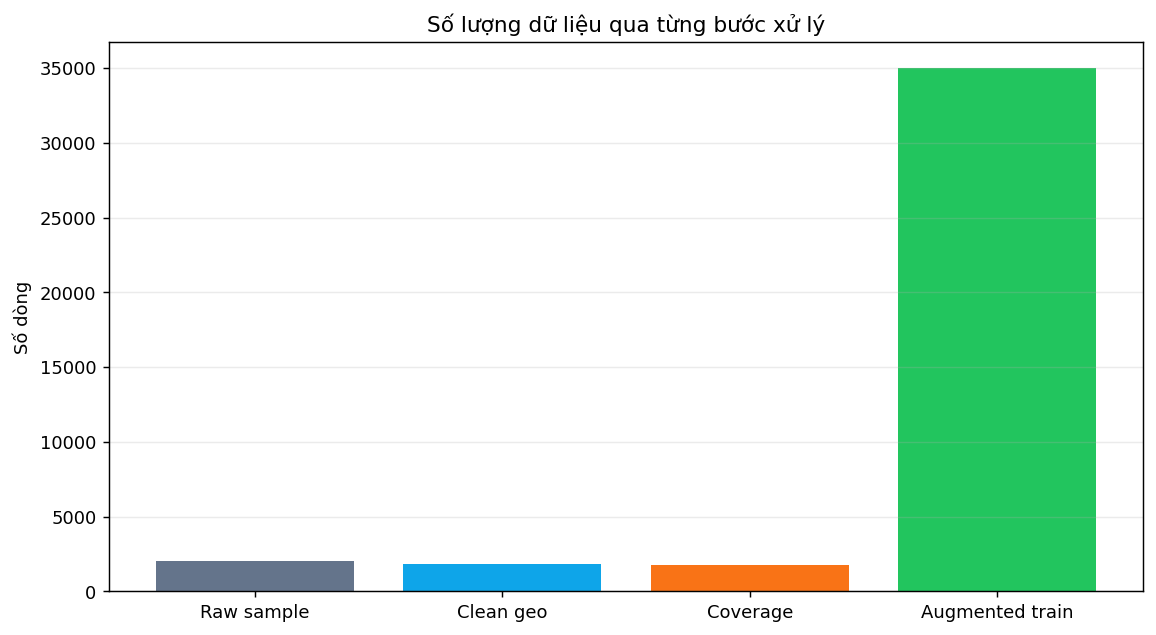

In [9]:
geo_df_for_train = geo_df.copy()
geo_df_for_train["is_market_coverage"] = False
coverage_df_for_train = coverage_df.copy()
coverage_df_for_train["is_market_coverage"] = True

base_df = pd.concat([geo_df_for_train, coverage_df_for_train], ignore_index=True)
augmented_df = tvm.augment_records(base_df)

print("Base shape:", base_df.shape)
print("Augmented shape:", augmented_df.shape)

counts = pd.DataFrame({
    "stage": ["Raw sample", "Clean geo", "Coverage", "Augmented train"],
    "rows": [len(raw_df), len(geo_df), len(coverage_df), len(augmented_df)],
})

plt.figure(figsize=(9, 5))
plt.bar(counts["stage"], counts["rows"], color=["#64748b", "#0ea5e9", "#f97316", "#22c55e"])
plt.ylabel("Số dòng")
plt.title("Số lượng dữ liệu qua từng bước xử lý")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(counts.to_string(index=False))


## 16. Feature engineering

Feature production:

```text
property_type_name
province_name
district_name
area
area_log
floor_count
bedroom_count
bathroom_count
latitude
longitude
```

Trong đó:

- Numeric dùng `StandardScaler`.
- Categorical dùng `OneHotEncoder(handle_unknown="ignore")`.
- `area_log = log1p(area)`.


In [10]:
feature_columns = [
    "property_type_name",
    "province_name",
    "district_name",
    "area",
    "area_log",
    "floor_count",
    "bedroom_count",
    "bathroom_count",
    "latitude",
    "longitude",
]

dataset = augmented_df.copy()
dataset["area_log"] = np.log1p(dataset["area"].clip(lower=1))
model_df = dataset[feature_columns + ["price"]].dropna().copy()

print("Model dataframe shape:", model_df.shape)
print("Province count:", model_df["province_name"].nunique())
print("Feature columns:")
for feature in feature_columns:
    print(" -", feature)


Model dataframe shape: (35000, 11)
Province count: 63
Feature columns:
 - property_type_name
 - province_name
 - district_name
 - area
 - area_log
 - floor_count
 - bedroom_count
 - bathroom_count
 - latitude
 - longitude


## 17. Train Ridge Linear Regression pipeline

Pipeline production:

```text
ColumnTransformer
  -> numeric: StandardScaler
  -> category: OneHotEncoder(handle_unknown="ignore")

Pipeline
  -> preprocess
  -> regressor: Ridge(alpha=2.0)

TransformedTargetRegressor
  -> log1p target
  -> expm1 output
```


In [11]:
model, metrics = tvm.train_model(
    dataset=augmented_df,
    raw_rows=len(raw_df),
    clean_geo_rows=len(geo_df),
)

print(json.dumps(metrics, ensure_ascii=False, indent=2))


{
  "source_dataset": "tinixai/vietnam-real-estates",
  "source_license": "cc-by-nc-4.0",
  "source_rows_total": 3500744,
  "raw_sample_rows": 2000,
  "clean_geo_rows": 1815,
  "coverage_rows": 17327,
  "training_rows": 35000,
  "training_province_count": 63,
  "expected_province_count": 63,
  "feature_columns": [
    "property_type_name",
    "province_name",
    "district_name",
    "area",
    "area_log",
    "floor_count",
    "bedroom_count",
    "bathroom_count",
    "latitude",
    "longitude"
  ],
  "target_column": "price",
  "model_type": "Ridge linear regression with log-transformed target",
  "mae_vnd": 1062219787,
  "r2": 0.9465,
  "model_file": "vietnam.pkl",
  "pipeline_file": "lr_pipeline.joblib",
  "market_calibration_note": "Raw Hugging Face observations are blended with practical province-level VND/m2 guardrails, then coverage rows are added so all 63 old provinces are represented.",
  "coordinate_note": "Dataset does not provide coordinates. Coordinates are assigned

## 18. Kết quả model

Bảng dưới là metrics chính của model production.


In [12]:
metrics_view = pd.DataFrame([{
    "model_type": metrics["model_type"],
    "training_rows": metrics["training_rows"],
    "province_count": metrics["training_province_count"],
    "mae_billion_vnd": round(metrics["mae_vnd"] / 1_000_000_000, 3),
    "r2": metrics["r2"],
    "raw_sample_rows": metrics["raw_sample_rows"],
    "clean_geo_rows": metrics["clean_geo_rows"],
    "coverage_rows": metrics["coverage_rows"],
}])
print(metrics_view.to_string(index=False))


                                         model_type  training_rows  province_count  mae_billion_vnd   r2  raw_sample_rows  clean_geo_rows  coverage_rows
Ridge linear regression with log-transformed target          35000              63             1.06 0.95             2000            1815          17327


## 19. So sánh giá thật và giá dự đoán trên tập test

Biểu đồ scatter càng sát đường chéo thì model càng dự đoán tốt.


MAE : 1.062 tỷ VND
RMSE: 2.686 tỷ VND
R2  : 0.9465


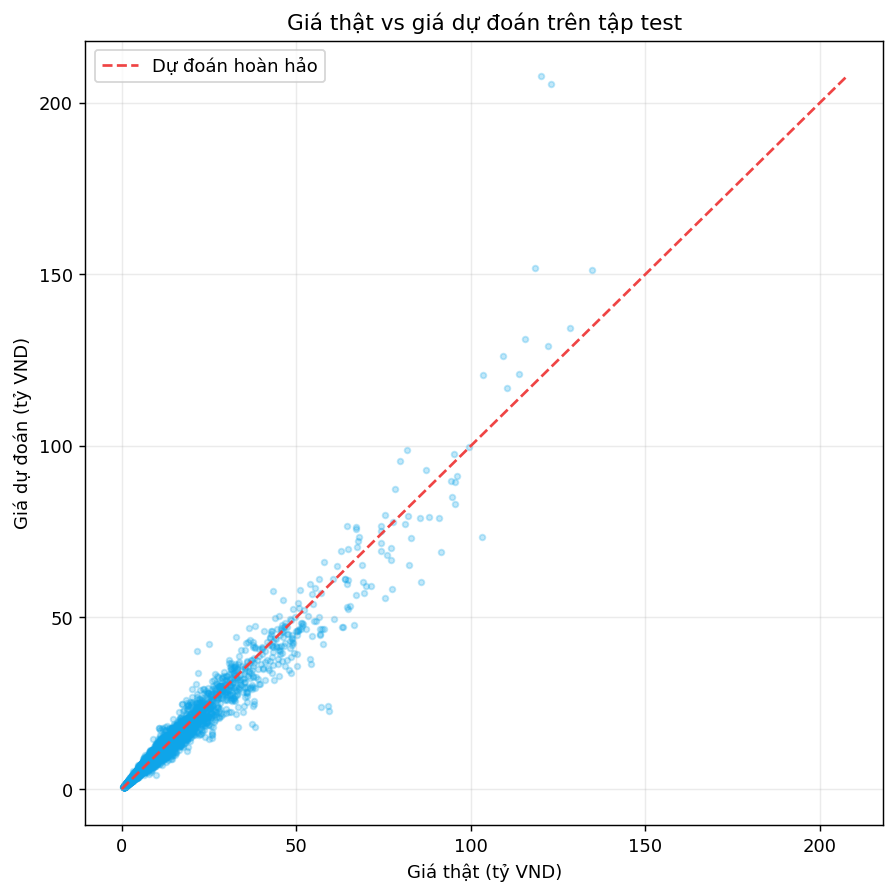

In [13]:
model_df_for_eval = augmented_df.copy()
model_df_for_eval["area_log"] = np.log1p(model_df_for_eval["area"].clip(lower=1))
eval_df = model_df_for_eval[feature_columns + ["price"]].dropna().copy()

x_train, x_test, y_train, y_test = train_test_split(
    eval_df[feature_columns],
    eval_df["price"],
    test_size=0.2,
    random_state=tvm.RANDOM_SEED,
)
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(7, 7))
plt.scatter(y_test / 1_000_000_000, y_pred / 1_000_000_000, s=10, alpha=0.25, color="#0ea5e9")
limit = max(float(y_test.max()), float(y_pred.max())) / 1_000_000_000
plt.plot([0, limit], [0, limit], "--", color="#ef4444", linewidth=1.5, label="Dự đoán hoàn hảo")
plt.xlabel("Giá thật (tỷ VND)")
plt.ylabel("Giá dự đoán (tỷ VND)")
plt.title("Giá thật vs giá dự đoán trên tập test")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"MAE : {mae / 1_000_000_000:,.3f} tỷ VND")
print(f"RMSE: {rmse / 1_000_000_000:,.3f} tỷ VND")
print(f"R2  : {r2:,.4f}")


### 19.1. Bảng metric đầy đủ

Bảng này trình bày đầy đủ các chỉ số đánh giá trên tập test:

- `MSE`: sai số bình phương trung bình.
- `RMSE`: căn bậc hai của MSE, cùng đơn vị với giá.
- `MAE`: sai số tuyệt đối trung bình.
- `R2`: tỷ lệ phương sai được mô hình giải thích.

Trong báo cáo/demo, nên nói RMSE và MAE theo đơn vị tỷ VND để dễ hiểu.


In [14]:
test_metrics_table = pd.DataFrame([
    {
        "metric": "MSE",
        "value_vnd": mean_squared_error(y_test, y_pred),
        "value_billion_vnd": mean_squared_error(y_test, y_pred) / 1_000_000_000,
        "explanation": "Sai số bình phương trung bình, phạt mạnh dự đoán lệch lớn",
    },
    {
        "metric": "RMSE",
        "value_vnd": rmse,
        "value_billion_vnd": rmse / 1_000_000_000,
        "explanation": "Sai số quy đổi về cùng đơn vị giá nhà",
    },
    {
        "metric": "MAE",
        "value_vnd": mae,
        "value_billion_vnd": mae / 1_000_000_000,
        "explanation": "Trung bình mỗi dự đoán lệch bao nhiêu tiền",
    },
    {
        "metric": "R2",
        "value_vnd": r2,
        "value_billion_vnd": r2,
        "explanation": "Tỷ lệ phương sai giá được mô hình giải thích",
    },
])

pretty_metrics = test_metrics_table.copy()
pretty_metrics["value_vnd"] = pretty_metrics["value_vnd"].map(lambda value: f"{value:,.0f}" if value > 10 else f"{value:,.4f}")
pretty_metrics["value_billion_vnd"] = pretty_metrics["value_billion_vnd"].map(lambda value: f"{value:,.4f}" if value <= 10 else f"{value:,.2f}")
print(pretty_metrics.to_string(index=False))


metric                 value_vnd value_billion_vnd                                               explanation
   MSE 7,212,577,571,143,526,400  7,212,577,571.14 Sai số bình phương trung bình, phạt mạnh dự đoán lệch lớn
  RMSE             2,685,624,242            2.6856                     Sai số quy đổi về cùng đơn vị giá nhà
   MAE             1,062,219,787            1.0622                Trung bình mỗi dự đoán lệch bao nhiêu tiền
    R2                    0.9465            0.9465              Tỷ lệ phương sai giá được mô hình giải thích


### 19.2. Bảng kết quả dự đoán chi tiết

Bảng này lấy một số dòng trong tập test để so sánh:

- Giá thật.
- Giá model dự đoán.
- Sai số tuyệt đối.
- Sai số phần trăm.

Đây là bảng nên mở khi demo để người nghe thấy model không chỉ có metric tổng quát mà còn có kết quả dự đoán cụ thể.


In [15]:
prediction_table = x_test.copy()
prediction_table["actual_price_vnd"] = y_test.values
prediction_table["predicted_price_vnd"] = y_pred
prediction_table["absolute_error_vnd"] = (prediction_table["actual_price_vnd"] - prediction_table["predicted_price_vnd"]).abs()
prediction_table["absolute_error_percent"] = (
    prediction_table["absolute_error_vnd"] / prediction_table["actual_price_vnd"].clip(lower=1)
) * 100

prediction_preview = prediction_table[[
    "province_name",
    "district_name",
    "property_type_name",
    "area",
    "floor_count",
    "bedroom_count",
    "bathroom_count",
    "actual_price_vnd",
    "predicted_price_vnd",
    "absolute_error_vnd",
    "absolute_error_percent",
]].sample(15, random_state=42).copy()

for col in ["actual_price_vnd", "predicted_price_vnd", "absolute_error_vnd"]:
    prediction_preview[col.replace("_vnd", "_billion_vnd")] = prediction_preview[col] / 1_000_000_000

prediction_preview = prediction_preview[[
    "province_name",
    "district_name",
    "property_type_name",
    "area",
    "actual_price_billion_vnd",
    "predicted_price_billion_vnd",
    "absolute_error_billion_vnd",
    "absolute_error_percent",
]]

print(prediction_preview.to_string(index=False))


 province_name district_name   property_type_name   area  actual_price_billion_vnd  predicted_price_billion_vnd  absolute_error_billion_vnd  absolute_error_percent
       Phú Thọ     Trung tâm                  Đất 115.76                      2.20                         2.28                        0.08                    3.62
        Hà Nội        Tây Hồ      Căn hộ chung cư  45.71                      4.55                         4.97                        0.42                    9.21
      Nam Định     Trung tâm                  Nhà  46.14                      1.20                         1.26                        0.06                    5.25
     Bình Định     Trung tâm Biệt thự/Nhà liền kề 113.88                      5.67                         5.42                        0.25                    4.38
   Thái Nguyên       Phổ Yên                  Đất  79.56                      2.12                         2.67                        0.55                   25.70
   Hồ Chí Minh  

### 19.3. Bảng sai số theo tỉnh/thành

Bảng này giúp giải thích model tốt/xấu ở từng khu vực. Những tỉnh có ít dữ liệu thật hoặc nhiều coverage rows có thể sai số khác nhau.


In [16]:
province_error_table = prediction_table.copy()
province_error_table["squared_error"] = (
    province_error_table["actual_price_vnd"] - province_error_table["predicted_price_vnd"]
) ** 2

province_summary = (
    province_error_table
    .groupby("province_name")
    .agg(
        samples=("actual_price_vnd", "count"),
        actual_avg_billion_vnd=("actual_price_vnd", lambda values: values.mean() / 1_000_000_000),
        predicted_avg_billion_vnd=("predicted_price_vnd", lambda values: values.mean() / 1_000_000_000),
        mae_billion_vnd=("absolute_error_vnd", lambda values: values.mean() / 1_000_000_000),
        rmse_billion_vnd=("squared_error", lambda values: np.sqrt(values.mean()) / 1_000_000_000),
    )
    .reset_index()
    .sort_values(["samples", "mae_billion_vnd"], ascending=[False, False])
)

print(province_summary.head(20).to_string(index=False))


    province_name  samples  actual_avg_billion_vnd  predicted_avg_billion_vnd  mae_billion_vnd  rmse_billion_vnd
      Hồ Chí Minh     1625                   16.31                      16.17             1.86              4.30
           Hà Nội     1345                   13.86                      13.64             1.69              2.81
          Đà Nẵng      337                   11.07                      10.64             1.70              4.06
       Bình Dương      198                    6.43                       6.53             0.61              1.03
        Khánh Hòa      153                    9.08                       8.62             1.31              2.67
         Đồng Nai      134                    8.06                       7.50             1.15              2.87
        Hải Phòng      122                    6.21                       5.92             0.69              1.14
          Long An      103                    7.43                       7.36             0.50  

### 19.4. Biểu đồ phân bố sai số

Biểu đồ này cho biết phần lớn dự đoán lệch trong khoảng nào. Nếu histogram tập trung gần 0, model đang ổn định hơn.


Sai số tuyệt đối trung vị: 0.401 tỷ VND
Sai số tuyệt đối trung bình: 1.062 tỷ VND
Sai số tuyệt đối P90: 2.499 tỷ VND


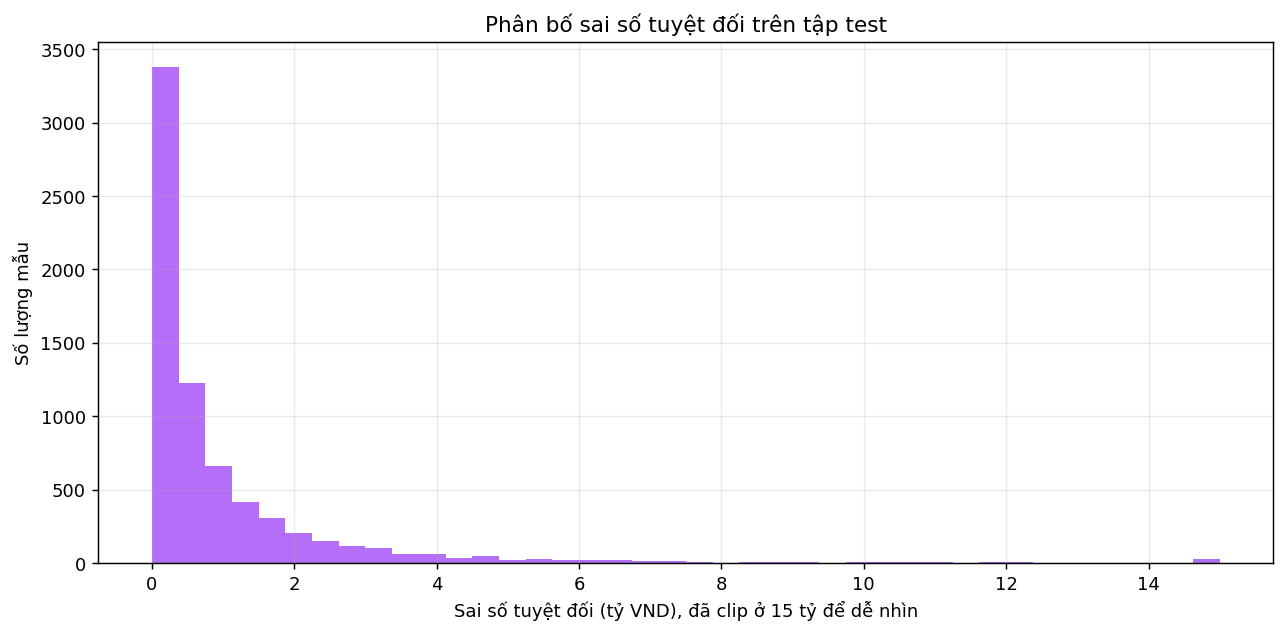

In [17]:
error_billion = prediction_table["absolute_error_vnd"] / 1_000_000_000

plt.figure(figsize=(10, 5))
plt.hist(error_billion.clip(upper=15), bins=40, color="#a855f7", alpha=0.85)
plt.xlabel("Sai số tuyệt đối (tỷ VND), đã clip ở 15 tỷ để dễ nhìn")
plt.ylabel("Số lượng mẫu")
plt.title("Phân bố sai số tuyệt đối trên tập test")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Sai số tuyệt đối trung vị:", f"{error_billion.median():,.3f} tỷ VND")
print("Sai số tuyệt đối trung bình:", f"{error_billion.mean():,.3f} tỷ VND")
print("Sai số tuyệt đối P90:", f"{error_billion.quantile(0.90):,.3f} tỷ VND")


## 20. Prediction mẫu cho một số tỉnh

Cell này tạo các căn nhà mẫu giống payload backend nhận, sau đó gọi model predict.


province_name district_name property_type_name  area  predicted_price_vnd  predicted_price_billion
       Hà Nội      Cầu Giấy                Nhà 80.00          15252518393                    15.25
  Hồ Chí Minh             1                Nhà 80.00          16830080469                    16.83
      Đà Nẵng      Hải Châu                Nhà 80.00           7828615835                     7.83
   Quảng Ngãi     Trung tâm                Nhà 80.00           3948861597                     3.95


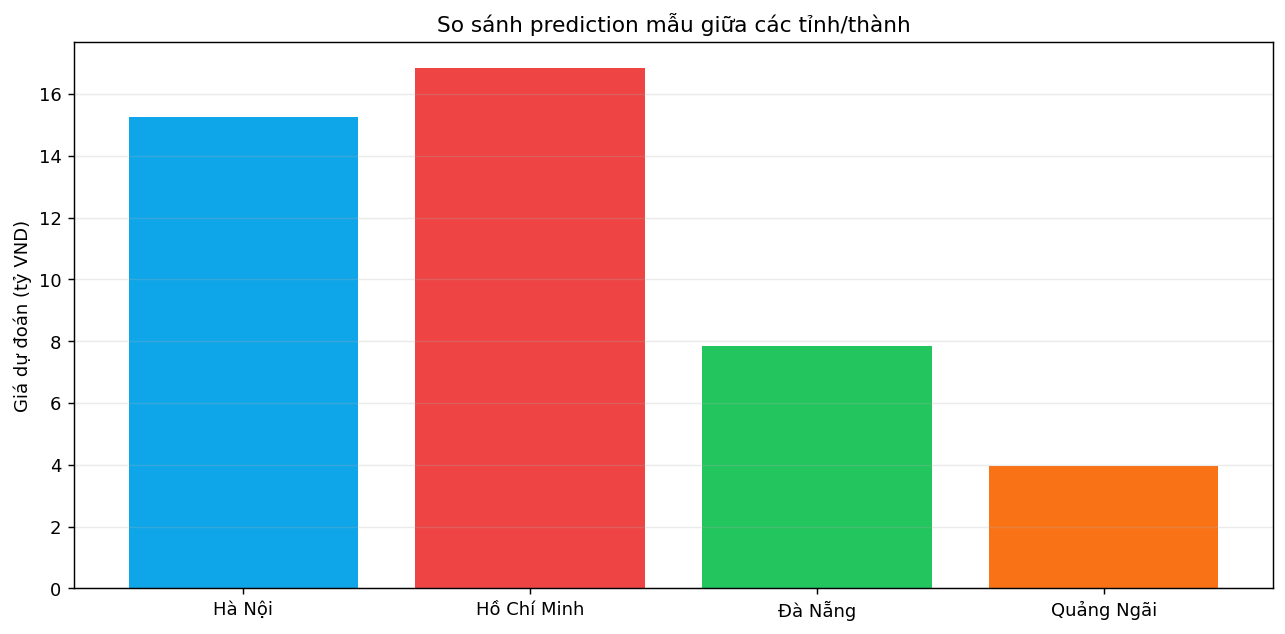

In [18]:
sample_inputs = pd.DataFrame([
    {
        "property_type_name": "Nhà",
        "province_name": "Hà Nội",
        "district_name": "Cầu Giấy",
        "area": 80.0,
        "area_log": np.log1p(80.0),
        "floor_count": 4.0,
        "bedroom_count": 4.0,
        "bathroom_count": 3.0,
        "latitude": 21.0362,
        "longitude": 105.7906,
    },
    {
        "property_type_name": "Nhà",
        "province_name": "Hồ Chí Minh",
        "district_name": "1",
        "area": 80.0,
        "area_log": np.log1p(80.0),
        "floor_count": 4.0,
        "bedroom_count": 4.0,
        "bathroom_count": 3.0,
        "latitude": 10.7769,
        "longitude": 106.7009,
    },
    {
        "property_type_name": "Nhà",
        "province_name": "Đà Nẵng",
        "district_name": "Hải Châu",
        "area": 80.0,
        "area_log": np.log1p(80.0),
        "floor_count": 3.0,
        "bedroom_count": 3.0,
        "bathroom_count": 2.0,
        "latitude": 16.0471,
        "longitude": 108.2068,
    },
    {
        "property_type_name": "Nhà",
        "province_name": "Quảng Ngãi",
        "district_name": "Trung tâm",
        "area": 80.0,
        "area_log": np.log1p(80.0),
        "floor_count": 3.0,
        "bedroom_count": 3.0,
        "bathroom_count": 2.0,
        "latitude": 15.1214,
        "longitude": 108.8044,
    },
])

predicted = model.predict(sample_inputs)
result = sample_inputs[["province_name", "district_name", "property_type_name", "area"]].copy()
result["predicted_price_vnd"] = np.round(predicted).astype("int64")
result["predicted_price_billion"] = result["predicted_price_vnd"] / 1_000_000_000

plt.figure(figsize=(10, 5))
plt.bar(result["province_name"], result["predicted_price_billion"], color=["#0ea5e9", "#ef4444", "#22c55e", "#f97316"])
plt.ylabel("Giá dự đoán (tỷ VND)")
plt.title("So sánh prediction mẫu giữa các tỉnh/thành")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(result.to_string(index=False))


## 21. Lưu model

Cell này mặc định không ghi đè model. Khi muốn train lại thật, đổi `SAVE_MODEL=True`.


In [19]:
SAVE_MODEL = False

if SAVE_MODEL:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, tvm.MODEL_PATH)
    joblib.dump(model, tvm.PIPELINE_MODEL_PATH)
    metrics_json = json.dumps(metrics, ensure_ascii=False, indent=2)
    tvm.METADATA_PATH.write_text(metrics_json, encoding="utf-8")
    tvm.PIPELINE_METRICS_PATH.write_text(metrics_json, encoding="utf-8")
    print("Đã lưu model và metrics vào:", MODEL_DIR)
else:
    print("SAVE_MODEL=False, không ghi đè model hiện tại.")


SAVE_MODEL=False, không ghi đè model hiện tại.


## 22. Backend Django dùng model như thế nào?

Backend load model từ:

```text
BE/ml_models/vietnam.pkl
BE/ml_models/vietnam_metadata.json
BE/ml_models/lr_pipeline_metrics.json
```

Flow API:

```text
PricePrediction.tsx
  -> POST /api/prediction/
  -> PricePredictionView
  -> PricePredictionInputSerializer
  -> PredictionService.predict_price()
  -> load BE/ml_models/vietnam.pkl
  -> tạo DataFrame đúng feature order
  -> model.predict()
  -> trả estimated_price, price_min, price_max, price_per_m2
```


In [20]:
backend_model_dir = ROOT_DIR.parent / "BE" / "ml_models"
backend_files = [
    backend_model_dir / "vietnam.pkl",
    backend_model_dir / "vietnam_metadata.json",
    backend_model_dir / "lr_pipeline_metrics.json",
]

for path in backend_files:
    print(f"{path.name:28} {'exists' if path.exists() else 'missing'}")


vietnam.pkl                  exists
vietnam_metadata.json        exists
lr_pipeline_metrics.json     exists


## 23. So sánh notebook cũ và notebook production

| Nội dung | Notebook cũ | Notebook production mới |
| --- | --- | --- |
| Mục tiêu | Minh họa Linear Regression | Train model dùng cho web thật |
| Model | `LinearRegression()` | `Ridge(alpha=2.0)` |
| Có tuyến tính không? | Có | Có |
| Dữ liệu | Hà Nội/Kaggle hoặc California theory | `tinixai/vietnam-real-estates` |
| Phạm vi | Hẹp hơn | 63 tỉnh/thành cũ |
| Categorical | `house_type` | `property_type_name`, `province_name`, `district_name` |
| Numeric | area, floors, rooms, lat/lng | area, area_log, floor, bedroom, bathroom, lat/lng |
| Target transform | thường dự đoán trực tiếp | log1p/expm1 |
| Output | demo model | `vietnam.pkl` cho backend |

Câu trả lời ngắn:

> Script mới vẫn dùng công thức Linear Regression giống nền tảng trong notebook cũ, nhưng bản production đổi sang Ridge Linear Regression để ổn định hơn, thêm log-transform target, thêm dữ liệu 63 tỉnh và đóng gói pipeline để backend Django sử dụng.


## 24. Kết luận

Notebook này chứng minh model production vẫn thuộc nhóm Linear Regression.

Các phần mở rộng gồm:

- Ridge regularization.
- StandardScaler cho biến số.
- OneHotEncoder cho biến phân loại.
- Log-transform target.
- Tọa độ tổng hợp.
- Market calibration.
- Coverage rows cho 63 tỉnh/thành.

Tất cả các bước này nhằm giúp model tuyến tính hoạt động ổn định hơn trên dữ liệu bất động sản Việt Nam và có thể tích hợp vào backend Django.
